# Evolution — how this port was actually built

**Audience:** an auditor of the engineering process asking "did the agent really
iterate, or did it skip the loop?"

Nine iterations, each with what changed, why, its admissibility class, and its
measured effect. Iterations 0–5 are the per-phase **ports**, recorded in
[`docs/ITERATION_LOG.md`](../docs/ITERATION_LOG.md). Iterations 6–8 are the
Phase 6 **acceleration search**, recorded in
[`docs/ACCELERATION_LOG.md`](../docs/ACCELERATION_LOG.md) in rebuildpy's strict
canonical schema.

**On missing data.** Iterations 1, 2 and 3 recorded no timings at all, and
iterations 0, 4 and 5 timed three different workloads, so they do not share an
axis. Rather than invent numbers to make a smooth curve, the plots below show
gaps where no measurement exists. A visible gap is honest; a fabricated point is
not. That is also why the aggregate figure at the end is built from the
acceleration log alone — it is the only sequence measured on a fixed
workload.

In [1]:
import os, pathlib, re, sys
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "RAYON_NUM_THREADS"):
    os.environ.setdefault(_v, "4")
REPO = pathlib.Path.cwd()
if REPO.name == "examples":
    REPO = REPO.parent
os.chdir(REPO)

import numpy as np
import matplotlib.pyplot as plt
import yaml
get_ipython().run_line_magic("matplotlib", "inline")

# (iteration, title, wall_clock_s or None, parity_metric or None, status)
HISTORY = [
    (0, "Baseline conv translation",        0.018, 1.788e-07, "port"),
    (1, "Phase 1 - loop module",            None,  9.537e-07, "port"),
    (2, "Phase 2 - domain + native TopDom", None,  5.960e-08, "port"),
    (3, "Phase 3+4 - compartment + embedding", None, 0.0,     "port"),
    (4, "Phase 5 - gene-score",             0.040, 0.0,       "port"),
    (5, "Phase 5 - contact-distance",       0.091, 0.0,       "port"),
    (6, "Accel baseline (Phase 5 close)",   0.1399, 0.0,      "baseline"),
    (7, "Accel - hoist mirror-index tables", 0.0946, 0.0,     "ACCEPT"),
    (8, "Accel - target-cpu=native",        0.0943, 0.0,      "REJECT_SLOW"),
    (9,  "Survey baseline (11 workloads)",  1.6000, 0.0,      "baseline"),
    (10, "Survey - hoist gaussian mirror-index", 1.5866, 0.0, "ACCEPT"),
    (11, "Survey - merge radix sort",       1.0527, 0.0,      "ACCEPT"),
]

# Iterations 6-8 are timed on a 3-workload benchmark; 9-11 on an 11-workload
# one. The absolute values are therefore NOT comparable across that boundary,
# which the panel below marks explicitly rather than letting the reader assume
# a regression at iteration 9.
BASIS_CHANGE_AT = 9
THRESHOLD = 1e-6

def panel(upto):
    """Two-panel subplot of the history so far, highlighting iteration `upto`."""
    sub = [h for h in HISTORY if h[0] <= upto]
    its = [h[0] for h in sub]
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))

    t = [h[2] for h in sub]
    known = [(i, v) for i, v in zip(its, t) if v is not None]
    if known:
        ax[0].plot([k[0] for k in known], [k[1] for k in known], "o-", color="tab:blue")
    missing = [i for i, v in zip(its, t) if v is None]
    for m in missing:
        ax[0].axvline(m, color="0.85", ls=":", zorder=0)
    if missing:
        ax[0].scatter(missing, [np.nan] * len(missing))
        ax[0].text(0.02, 0.06, "dotted = no timing recorded", transform=ax[0].transAxes,
                   fontsize=8, color="0.4")
    if upto in [h[0] for h in known]:
        v = dict(known)[upto]
        ax[0].scatter([upto], [v], s=170, facecolors="none", edgecolors="red", zorder=5)
    ax[0].set_yscale("log"); ax[0].set_xlabel("iteration")
    ax[0].set_ylabel("wall-clock (s)"); ax[0].set_title("Wall-clock (lower is better)")
    if upto >= BASIS_CHANGE_AT:
        ax[0].axvline(BASIS_CHANGE_AT - 0.5, color="tab:orange", ls="--", lw=1.4)
        ax[0].text(BASIS_CHANGE_AT - 0.45, ax[0].get_ylim()[1] * 0.55,
                   "benchmark widened 3 -> 11 workloads" + chr(10) + "(totals not comparable)",
                   fontsize=7, color="tab:orange")
    ax[0].set_xlim(-0.5, len(HISTORY) - 0.5); ax[0].grid(alpha=0.3)

    p = [h[3] for h in sub]
    pk = [(i, v) for i, v in zip(its, p) if v is not None]
    ax[1].plot([k[0] for k in pk], [max(k[1], 1e-18) for k in pk], "o-", color="tab:green")
    ax[1].axhline(THRESHOLD, color="red", ls="--", label="threshold = 1e-6")
    if upto in dict(pk):
        ax[1].scatter([upto], [max(dict(pk)[upto], 1e-18)], s=170,
                      facecolors="none", edgecolors="red", zorder=5)
    ax[1].set_yscale("log"); ax[1].set_xlabel("iteration")
    ax[1].set_ylabel("worst parity metric"); ax[1].set_title("Parity (must stay below the line)")
    ax[1].set_xlim(-0.5, len(HISTORY) - 0.5); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

    plt.suptitle(f"through iteration {upto}: {dict((h[0], h[1]) for h in HISTORY)[upto]}",
                 fontsize=10)
    plt.tight_layout(); plt.show()

print("history entries:", len(HISTORY))

history entries: 12


## Iteration 0 — Baseline translation — `convolve2d_mirror`

Phase 0 scaffolded the rebuildpy artefacts, pre-registered `data/manifest.yaml`,
and ported one primitive: `scipy.ndimage.convolve(mode='mirror')` as
`rust/src/conv.rs`. It is a direct translation — parallel across output rows,
each row's reduction serial and fixed-order — so admissibility is **(E) exact**,
with no perturbation bound needed. The `mirror_index` helper was shared with the
pre-existing `gaussian_filter_2d` via `utils.rs`.

The expected effect was a speedup; the measured effect was the opposite. On the
64×64 gate fixture Rust took 0.018 s against scipy's 0.0052 s. That was written
off at the time as thread-spawn overhead on a tiny input — a conclusion
iteration 6 later showed to be wrong.
[ITER_LOG ↩](../docs/ITERATION_LOG.md)

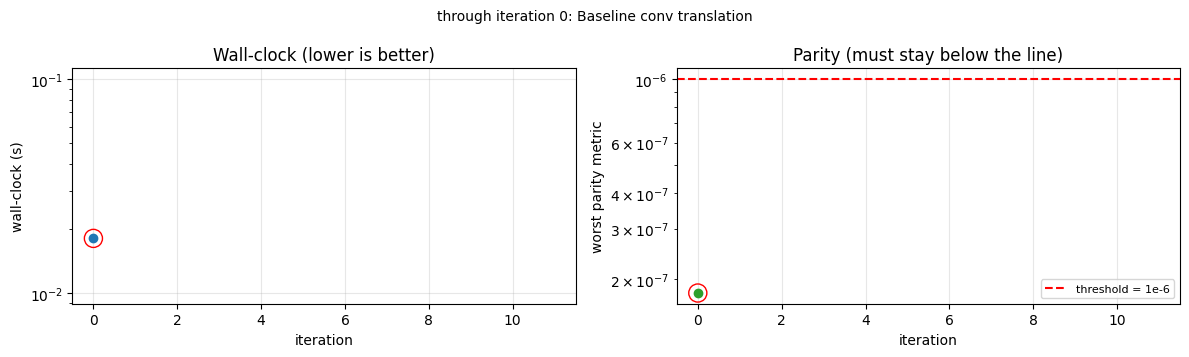

In [2]:
panel(0)

## Iteration 1 — Phase 1 — loop module

Whole-function ports of `calculate_chrom_background_normalization`,
`merge_cells_for_single_chromosome`, `loop_background` and `find_summit`. All
five convolutions in the loop pipeline reuse the Phase 0 primitive. `merge`
accumulates in an f64 `BTreeMap` so cross-cell emission is deterministic
row-major, and `find_summit` uses a `BinaryHeap` with an ascending-index
tie-break to match Python `heapq`'s insertion-order stability. All (E).

Ten manifest outputs turned green. One real bug surfaced: `percentile_linear`
was sorting its input slice **in place**, corrupting the downstream z-score;
fixed by sorting a copy. No wall-clock was recorded for this phase, which is why
the left panel shows a gap.
[ITER_LOG ↩](../docs/ITERATION_LOG.md)

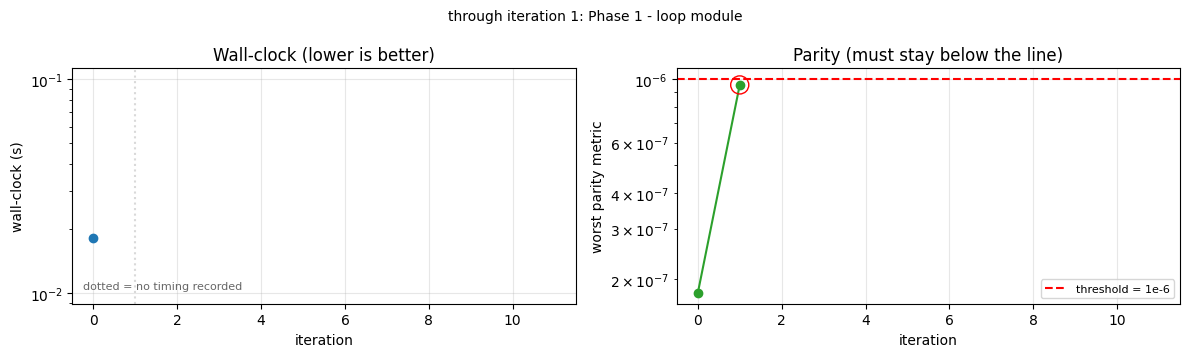

In [3]:
panel(1)

## Iteration 2 — Phase 2 — domain module, native TopDom

The biggest equivalence risk in the whole port: a full native TopDom
(`topdom.rs`, 581 lines) replacing the rpy2 → `TopDom.R` round-trip, plus
`insulation.rs`. It reproduces R's diamond mean signal, gap detection,
change-point and local-extreme detection, `wilcox.test(exact=F,
alternative="less")` with continuity and tie correction, and
`Convert.Bin.To.Domain.TMP`. The normal CDF uses an inline Abramowitz erf
(~1.5e-7), ample for a `p < 0.05` cut. All (E), no new crate dependencies.

This removed R from the dependency chain entirely. One off-by-one appeared in
the *Python* wrapper, not the Rust: `chromEnd` used `to_coord[to_id]` where R
uses the next row's `from.coord`, cutting every domain 10 kb short. The Rust
kernel was correct on the first build.
[ITER_LOG ↩](../docs/ITERATION_LOG.md)

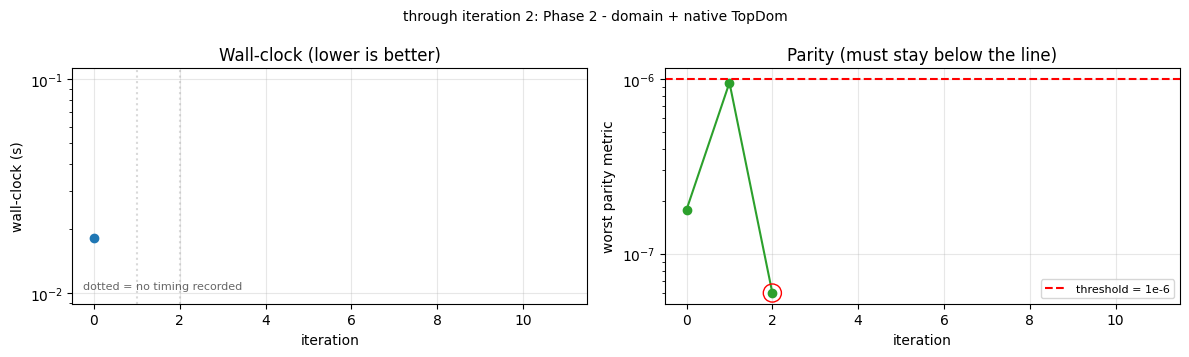

In [4]:
panel(2)

## Iteration 3 — Phase 3+4 — compartment + embedding

`single_chrom_compartment` with f64 accumulators throughout, and
`make_chrom_matrix`'s extraction kernel. Embedding is a pure f32 gather plus one
scalar multiply with **no reduction**, so it meets a `deterministic-strict` gate
at `atol=0` — exact bit-equality is the only meaningful tolerance for an
index-and-scale operation. SVD stays sklearn by design: it is not a bottleneck
and has no element-wise parity.

The final three outputs turned green, taking the gate to 17/17. A harness bug
surfaced: rebuildpy's `is_pass()` used a strict `<` against the threshold, which
makes `threshold: 0.0` mathematically unreachable; patched locally in
`tests/parity_harness.py` to use `<=` for that case. Manifest values untouched.
[ITER_LOG ↩](../docs/ITERATION_LOG.md)

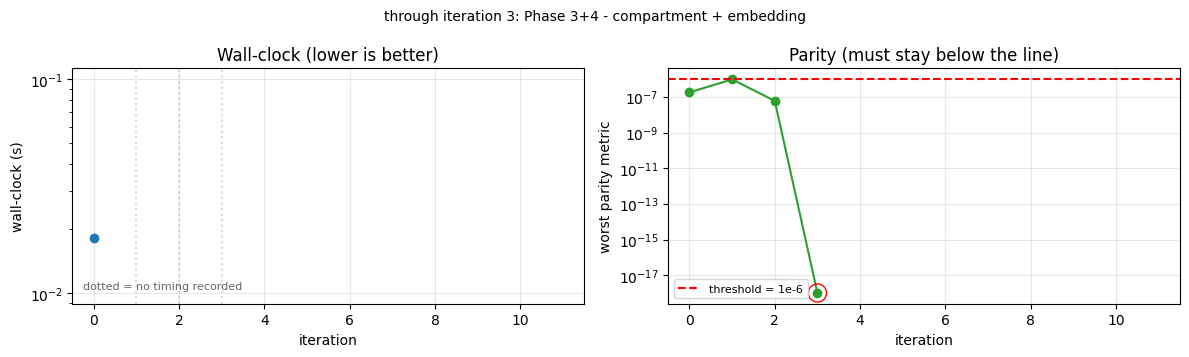

In [5]:
panel(3)

## Iteration 4 — Phase 5 — gene-score

The per-gene window-sum loop, which upstream evaluates as `D[r0:r1,
c0:c1].sum()` once per gene — 78,691 scipy submatrix allocations per cell on a
real human gene set. The kernel binary-searches each row's sorted column indices
instead, parallel across genes, each gene's reduction fixed-order: **(E)**.

This is where the port nearly went wrong. `csr.sum(axis=None)` is *not* a flat
`data.sum()`; scipy computes it as `(self @ ones(n_cols)).sum()` — a serial
per-row matvec followed by pairwise summation over the row sums, in the
matrix's own dtype. Imputed cools are f32, so upstream's own answer carries
~3.8e-6 of rounding. A straight f64 accumulation is *more accurate* and
therefore lands 3.35e-6 away, failing the pre-registered 1e-6 gate; a flat f32
pairwise sum fails too, at 3.81e-6. Reproducing scipy's two-stage order makes it
bit-exact. The gate was never widened.
[ITER_LOG ↩](../docs/ITERATION_LOG.md)

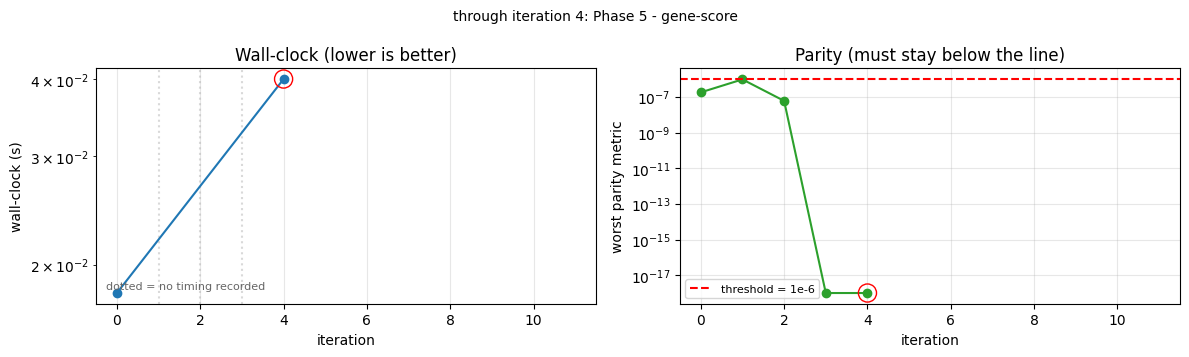

In [6]:
panel(4)

## Iteration 5 — Phase 5 — contact-distance

`compute_decay` ported as a streaming reader: `flate2::MultiGzDecoder` plus a
`BufReader`, parsing four columns per line in constant memory, with no DataFrame
ever built. This is the one deliberate move of the I/O seam in the whole port,
justified because the cost being removed *is* the read. First I/O dependency in
the crate; the pure-Rust miniz_oxide backend keeps the wheel matrix portable.

`np.histogram`'s edge rules are reproduced exactly — right-open bins except a
right-closed final bin, out-of-range values dropped. For hg38 the top edge is
~231.7 Mb against a 249.0 Mb chr1, so upstream silently drops the longest cis
contacts, and so does this port. Both outputs are integer counts, so both gate
`deterministic-strict`. Gate reached 21/21.
[ITER_LOG ↩](../docs/ITERATION_LOG.md)

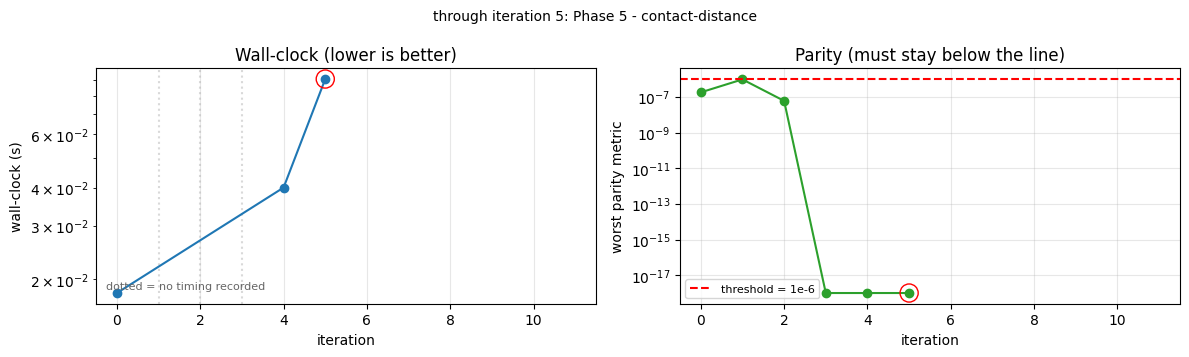

In [7]:
panel(5)

## Iteration 6 — Acceleration baseline — measure before optimising

Phase 6 opened by building a fixed benchmark (`examples/bench_phase6.py`) at
realistic sizes, timed under rebuildpy's protocol: BLAS and rayon pinned to 4
threads, one warmup run discarded, then three timed runs.

Two earlier records turned out to be wrong. First, `conv2d_mirror` is genuinely
**slower than scipy** — 0.0740 s against 0.0692 s at 1024×1024 with an 11×11
kernel — so iteration 0's "thread-spawn overhead on a tiny input" explanation
does not hold, and this is the crate's one real acceleration target. Second,
gene-score's Phase 5 headline of 46.3× was warmup-inclusive; excluding
thread-pool spin-up, the same workload is 217.6×. No code changed here, only
measurement.
[ACCEL_LOG ↩](../docs/ACCELERATION_LOG.md)

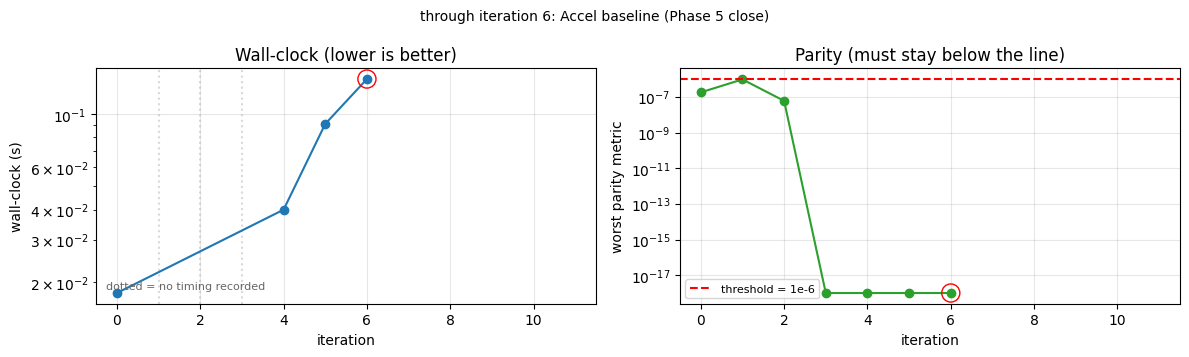

In [8]:
panel(6)

## Iteration 7 — Acceleration — hoist the mirror-index tables (accepted)

The conv inner loop called `mirror_index` once per `(i, j, p, q)` — a modulo and
two branches, ~127M times for the benchmark input. But the column mirror depends
only on `(j, q)` and the row mirror only on `(i, p)`; neither belonged in the
innermost loop. Both are now tabulated once per call, and the kernel is
pre-flipped so the inner loop reads it forwards.

Pure integer tabulation of a data-independent function: the float operand
sequence is untouched, so this is **(E) exact**, and the proof is empirical —
`conv.convolved` held its metric at exactly `1.7881393432617188e-07`, the same
value iteration 0 recorded. conv went 0.0740 → 0.0306 s (2.42×), flipping it
from 0.9× to **2.3× faster than scipy**. Total benchmark wall-clock 0.1399 →
0.0946 s.
[ACCEL_LOG ↩](../docs/ACCELERATION_LOG.md)

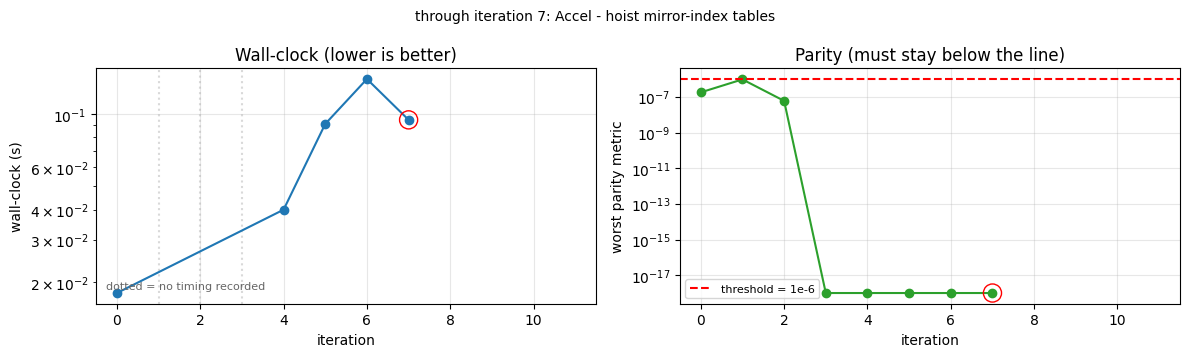

In [9]:
panel(7)

## Iteration 9 — Survey — profile every kernel, not just three

The first acceleration pass benchmarked three workloads. Nothing had ever
established whether the other eight kernels were fast, so
`examples/bench_phase6.py` was extended to **eleven — one per kernel** — and
every one measured against a Python reference.

Two came back **slower than Python**: `merge` at 0.1× (eight times slower than
scipy's sparse addition) and, on real data, the impute path's Gaussian filter.
Two of my own references were also wrong and had inverted their verdicts:
`compartment` first read 0.1× because the reference skipped
`compartment_strength` while the Rust call computed it (truly 22.3× faster),
and `merge` first read 2.8× *faster* against a pure-Python dict loop instead of
scipy (truly 0.1×). A bad reference does not report "no result" — it reports a
confident wrong result, with an unpredictable sign.

No code changed in this iteration; the wall-clock jump is the benchmark
widening from 3 workloads to 11, marked on the plot.
[ACCEL_LOG ↩](../docs/ACCELERATION_LOG_SURVEY.md)

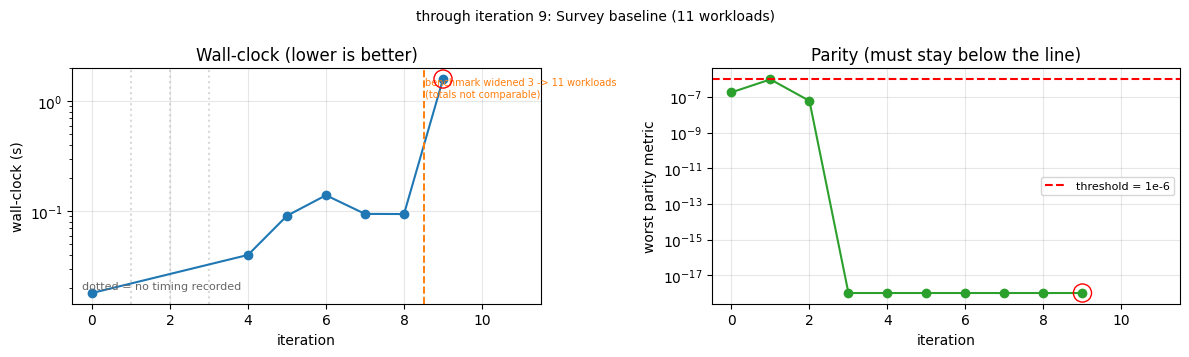

In [10]:
panel(9)

## Iteration 10 — Survey — hoist the Gaussian's mirror-index tables (accepted)

Iteration 7 fixed `conv.rs` and the report claimed the impute path inherited it.
**That was wrong.** `lib.rs` has its own separable `gaussian_filter_2d` that
never calls `convolve2d_mirror`, and it carried the identical defect —
`mirror_index` recomputed per `(i, j, kx)`, twice over the two separable
passes, ~367M integer modulos for a 25 kb chr1.

Same (E)-exact fix, and verified on real data rather than only the gate:
re-imputing real cells gives `max|new − old| = 0.0`, bit-identical, with the
error against upstream unchanged at 4.47e-08.

The synthetic workload barely moves (1.03×) because at 2048² the RWR fixed
point dominates. The real-data harness tells the true story: **100 kb chr19
goes from 1.04× to 3.68× against upstream** — that configuration previously
bought a user essentially nothing, because once the matrix is small enough for
RWR not to dominate, the un-hoisted Gaussian did.
[ACCEL_LOG ↩](../docs/ACCELERATION_LOG_SURVEY.md)

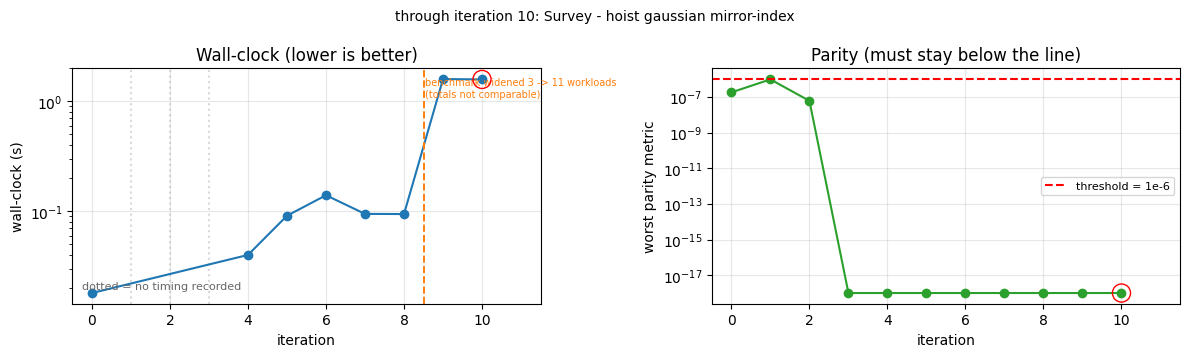

In [11]:
panel(10)

## Iteration 11 — Survey — replace merge's BTreeMap with a stable radix sort (accepted)

`merge.rs` used two `BTreeMap<(u32, u32), f64>`, so every input triplet paid two
O(log k) tree descents with a heap-allocated node per unique key — 4M tree
operations and ~2M allocations for 50 cells × 40k nnz. That is why it was 8×
slower than scipy doing the same job at C level.

The BTreeMap was not an accident: Phase 1 chose it to guarantee deterministic
row-major emission, and that requirement is real. The rewrite keeps the
guarantee and drops the cost — a packed `row*ncols+col` key sorts row-major by
construction, and an LSD radix sort is **stable**, so each key's f64 additions
keep their input order. Stability is load-bearing: `sort_unstable_by_key` was
measured 2× faster still and is deliberately unused, because reordering those
additions would make the rewrite (B).

merge went 0.571 → 0.055 s (**10.4×**), flipping **0.1× → 1.5× vs scipy**, with
`merge.e_sum` and `merge.e2_sum` holding the exact metrics they have had since
Phase 1.
[ACCEL_LOG ↩](../docs/ACCELERATION_LOG_SURVEY.md)

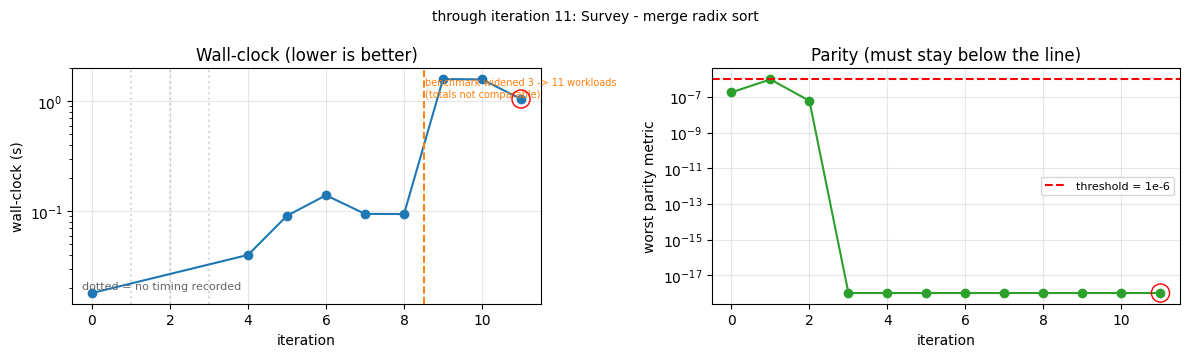

In [12]:
panel(11)

## Iteration 8 — Acceleration — `target-cpu=native` (rejected, no gain)

Rebuilt with `RUSTFLAGS="-C target-cpu=native"`. Admissibility was verified
rather than assumed: the full 21-output gate stayed green with every metric
bit-identical to the portable build, confirming that no kernel enables
reassociating fast-math flags and that wider vector units still execute the same
fixed-order reduction. So it is **(E)**.

It was rejected anyway, for no speedup: 0.0943 s against 0.0946 s, a 0.3%
difference on a summed stddev of ~0.0008 — indistinguishable from noise. In
hindsight that is unsurprising. After iteration 7 the conv loop is bound by
memory access through two index tables, and the other kernels by gzip inflate
and sparse-index chasing; none is a dense FMA loop. `Cargo.toml` is unchanged
and the shipped wheel stays portable, and `PERFORMANCE.md` does not advertise a
knob that buys nothing.

A fourth candidate — a prefix-sum sliding window for insulation — was rejected
**as inadmissible** rather than measured: `P[b] - P[a]` makes the error scale
with the chromosome length rather than the window length, making it a (B)
rewrite, out of scope under this phase's (E)-only policy. It has no iteration
of its own here because nothing was built.
[ACCEL_LOG ↩](../docs/ACCELERATION_LOG.md)

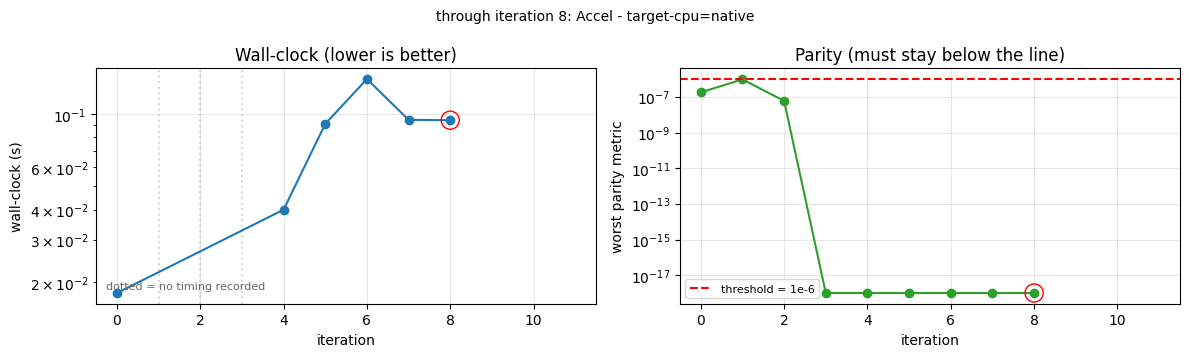

In [13]:
panel(8)

## Aggregate evolution figure

Two figures, because there are two searches on two different workload sets.
The first is the conv-focused pass over 3 workloads
([`ACCELERATION_LOG.md`](../docs/ACCELERATION_LOG.md)); the second is the
full-kernel survey over 11
([`ACCELERATION_LOG_SURVEY.md`](../docs/ACCELERATION_LOG_SURVEY.md)). Their
totals are not comparable, so they are deliberately not drawn on one axis.
`plot_evolution` plots only entries whose status is `baseline` or `ACCEPT`, so
rejected candidates stay in the logs but out of the curves.

[plot] wrote examples/evolution.png


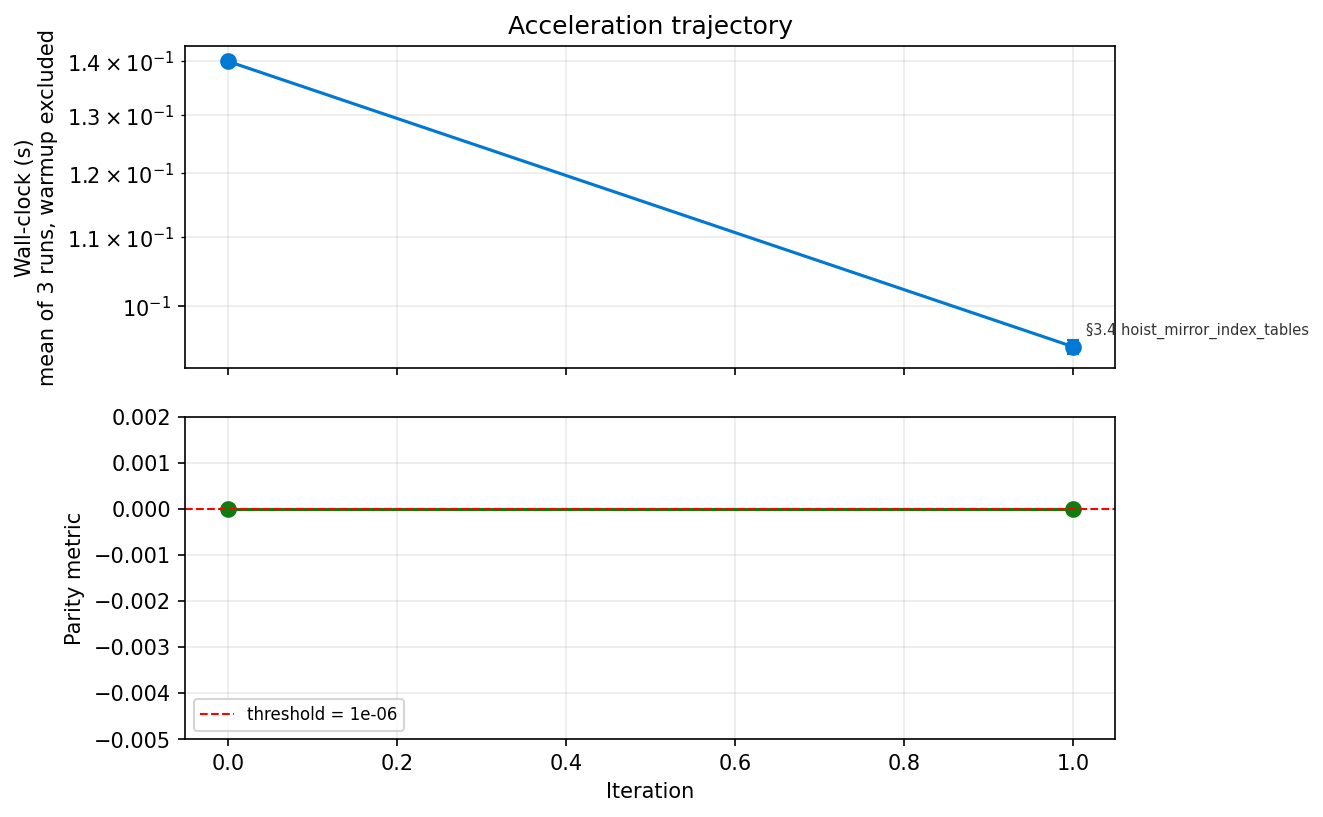

[plot] wrote examples/evolution_survey.png


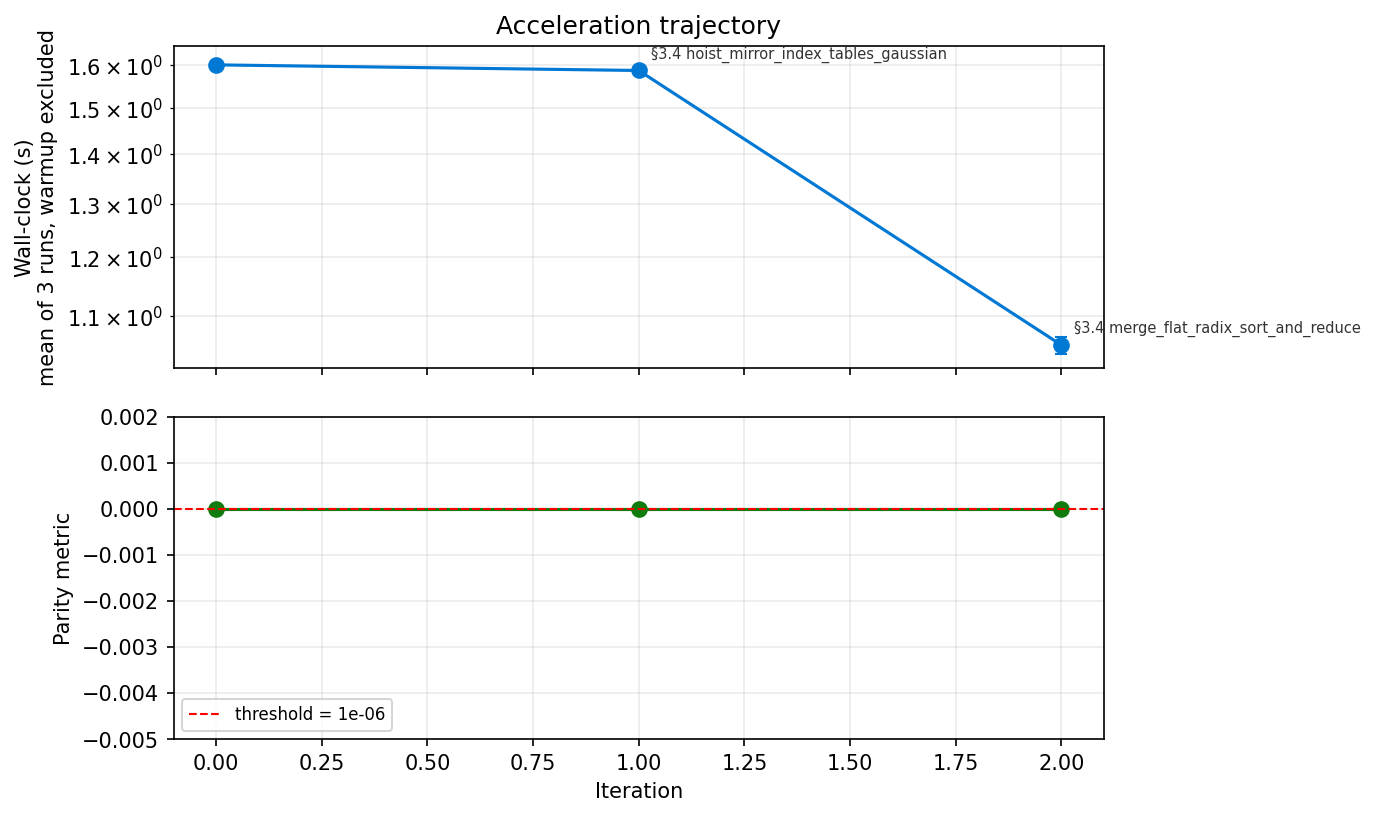

In [14]:
import subprocess
r = subprocess.run([sys.executable, "-m", "engine.plot_evolution",
                    "--port-dir", ".", "--log", "docs/ACCELERATION_LOG.md",
                    "--output", "examples/evolution.png", "--threshold", "1e-6"],
                   capture_output=True, text=True,
                   env={**os.environ, "PYTHONPATH": "/large_storage/zhoulab/shengmao/rebuildpy"})
print(r.stdout.strip() or r.stderr.strip()[-400:])

from IPython.display import Image, display
display(Image(filename="examples/evolution.png"))

r2 = subprocess.run([sys.executable, "-m", "engine.plot_evolution",
                     "--port-dir", ".", "--log", "docs/ACCELERATION_LOG_SURVEY.md",
                     "--output", "examples/evolution_survey.png", "--threshold", "1e-6"],
                    capture_output=True, text=True,
                    env={**os.environ, "PYTHONPATH": "/large_storage/zhoulab/shengmao/rebuildpy"})
print(r2.stdout.strip() or r2.stderr.strip()[-400:])
display(Image(filename="examples/evolution_survey.png"))

In [15]:
# Full history table, including the entries the aggregate figure cannot show.
print(f"{'iter':>4}  {'status':<12} {'wall-clock':>12}  {'parity':>12}  title")
print("-" * 88)
for n, title, t, p, status in HISTORY:
    ts = f"{t:.4f} s" if t is not None else "not recorded"
    ps = f"{p:.3e}" if p is not None else "—"
    print(f"{n:>4}  {status:<12} {ts:>12}  {ps:>12}  {title}")
print()
print("Rejected candidates retained in docs/ACCELERATION_LOG.md but absent from the figure:")
print("   iter 2 (log) target_cpu_native            REJECT_SLOW          — admissible, no gain")
print("   iter 3 (log) prefix_sum_insulation_window REJECT_INADMISSIBLE  — (B), never built")

iter  status         wall-clock        parity  title
----------------------------------------------------------------------------------------
   0  port             0.0180 s     1.788e-07  Baseline conv translation
   1  port         not recorded     9.537e-07  Phase 1 - loop module
   2  port         not recorded     5.960e-08  Phase 2 - domain + native TopDom
   3  port         not recorded     0.000e+00  Phase 3+4 - compartment + embedding
   4  port             0.0400 s     0.000e+00  Phase 5 - gene-score
   5  port             0.0910 s     0.000e+00  Phase 5 - contact-distance
   6  baseline         0.1399 s     0.000e+00  Accel baseline (Phase 5 close)
   7  ACCEPT           0.0946 s     0.000e+00  Accel - hoist mirror-index tables
   8  REJECT_SLOW      0.0943 s     0.000e+00  Accel - target-cpu=native
   9  baseline         1.6000 s     0.000e+00  Survey baseline (11 workloads)
  10  ACCEPT           1.5866 s     0.000e+00  Survey - hoist gaussian mirror-index
  11  ACCEPT     